In [1]:
import numpy as np
import cv2
import glob
import pandas as pd

In [2]:
path = r'G:\DESKTOP FILES\desktop\MRNet-v1.0\MRNet-v1.0'
df_abnormal = pd.read_csv(path+"\\train-abnormal.csv", header=None, names=['case', 'abnormal'])
df_acl = pd.read_csv(path+"\\train-acl.csv", header=None, names=['case', 'acl'])
df_meniscus = pd.read_csv(path+"\\train-meniscus.csv", header=None, names=['case', 'meniscus'])

In [3]:
train_df = pd.merge(df_abnormal, df_acl, on='case').merge(df_meniscus, on='case')

In [4]:
train_df

,case,abnormal,acl,meniscus
0,0,1,0,0
1,1,1,1,1
2,2,1,0,0
3,3,1,0,1
4,4,1,0,0
...,...,...,...,...
1125,1125,1,0,1
1126,1126,1,0,1
1127,1127,0,0,0
1128,1128,1,0,0


In [5]:
images_axial = glob.glob(r"G:\DESKTOP FILES\desktop\MRNet-v1.0\MRNet-v1.0\train\axial\*.npy")
images_coronal = glob.glob(r"G:\DESKTOP FILES\desktop\MRNet-v1.0\MRNet-v1.0\train\coronal\*.npy")
images_sagittal = glob.glob(r"G:\DESKTOP FILES\desktop\MRNet-v1.0\MRNet-v1.0\train\sagittal\*.npy")

In [6]:
x1 = []
for i in images_axial:
    x1.append(np.load(i))
x2 = []
for i in images_coronal:
    x2.append(np.load(i))
x3 = []
for i in images_sagittal:
    x3.append(np.load(i))

In [7]:
maximum_axial = max(arr.shape for arr in x1)
maximum_coronal = max(arr.shape for arr in x2)
maximum_sagittal = max(arr.shape for arr in x3)

In [8]:
maximum_axial[0]

61

In [9]:
maximum_coronal[0]

58

In [10]:
maximum_sagittal[0]

51

In [11]:
from tqdm import tqdm
padded_axial_images = []

for i in tqdm(range(0, len(images_axial))):
    img = np.load(images_axial[i])
    if(img.shape[0] < maximum_axial[0]):
        diff = maximum_axial[0] - img.shape[0]
        last_img = np.zeros((50,50))
        temp = []

        k = 0
        while k < img.shape[0]:
            if k == img.shape[0]:
                break
            temp_img =  cv2.resize(img[k],[50,50])
            temp.append(temp_img)
            k = k+1
            
        for k in range (0 , diff):
            temp.append(last_img)
        padded_axial_images.append(temp)

100%|██████████████████████████████████████████████████████████████████████████████| 1130/1130 [00:27<00:00, 41.24it/s]


In [19]:
len(padded_axial_images)

1128

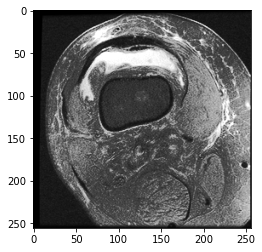

In [24]:
from matplotlib import pyplot as plt

plt.imshow(x1[10][0], cmap='gray')
plt.show()

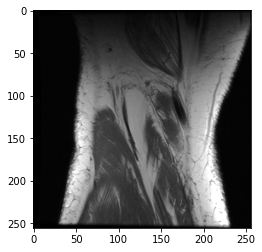

In [25]:
plt.imshow(x2[10][0], cmap='gray')
plt.show()

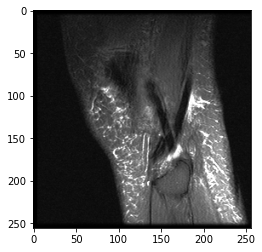

In [26]:
plt.imshow(x3[10][1], cmap='gray')
plt.show()